<a href="https://colab.research.google.com/github/ravichas/bifx-546/blob/main/Notebooks/Chapter08_GradientDescent_ver2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Chapter 8: Gradient Descent

🎓 Course Context

Prepared for BIFX-546 – Machine Learning for Bioinformatics

Instructor: Sarangan Ravichandran, PhD., PMP

# 📘 Attribution & Reading Reference

This notebook is based on concepts, structure and examples from,

Data Science from Scratch, 2nd Edition by Joel Grus, published by O'Reilly Media, Inc.

# Relevant Reading:

Data Science from Scratch, 2nd Edition — Chapter 8: [Gradient Descent]

The material in this notebook has been **expanded with additional explanations, new examples, and code adaptations** to support instructional use and execution in a Google Colab Environment. Any additions, reformatting, or implementation details beyond the original text are the responsibility of the notebook author.

This notebook is intended for educational use only and does not replace the original book/code examples.

## ✅ Notebook Summary

This notebook introduces **Gradient Descent** as a general-purpose optimization method and shows how it is used to fit model parameters in machine learning.

### What you’ll learn
- What a **gradient** is (a single vector of partial derivatives) and why Gradient Descent (GD) moves in the **negative gradient** direction
- How the **dot product** connects small parameter changes to approximate loss change:  $(\Delta f \approx \nabla f \cdot \Delta \mathbf{x})$
- Why we need numerical optimization when **closed-form solutions** are not available
- How to implement/update parameters using:
  - **Batch Gradient Descent**
  - **Mini-batch Gradient Descent**
  - **Stochastic Gradient Descent (SGD)**

### What you’ll do
- Run small examples (sum-of-squares minimization)
- Use gradient-based updates to fit a **linear model** $(\hat{y} = mx + b)$

### How to run in Colab
1. Run the **repo setup / clone** cell (adds Grus’ `scratch/` modules to the environment)
2. Run cells top-to-bottom (some later code assumes earlier imports + helper functions)

### Key takeaway
Gradient descent is an **iterative method**: compute a gradient → take a small step downhill → repeat until improvement stops.

## Gradient Descent (GD)

Gradient Descent is a method for finding the minimum of a function (the lowest point).

A common analogy is walking downhill on a foggy mountain:

- From your current position, you look at the slope (the **gradient**) to determine which direction goes **uphill** the fastest.
- To go downhill, you take a small step in the **opposite direction** (the **negative gradient**).
- You repeat until your steps no longer reduce the function value (or you reach a stopping condition).

In machine learning, gradient descent is how we adjust model parameters (e.g., weights in a neural network) to reduce error on training data.

Let:

$$f(x,y) = x^2 + y^2$$

Compute partial derivatives:

$$
\frac{\partial f}{\partial x} = 2x
$$
$$
\frac{\partial f}{\partial y} = 2y
$$

So the gradient is:

$$\nabla f = (2x, 2y)$$

At point (3,4):

$$\nabla f = (6,8)$$

That is one vector.

Not two vectors combined.
Not separate pieces.

Just one vector whose components are the partial derivatives.

Suppose you move a tiny step:

$$\Delta \mathbf{x} = (\Delta x, \Delta y)$$

The change in f is approximately:

$$
\Delta f \approx
\frac{\partial f}{\partial x}\Delta x
+
\frac{\partial f}{\partial y}\Delta y
$$

This equals:

$$\nabla f \cdot \Delta \mathbf{x}$$

In other words, this is equal to

$$
\begin{bmatrix}
\frac{\partial f}{\partial x} & \frac{\partial f}{\partial y}
\end{bmatrix}
\begin{bmatrix}
\Delta x \\
\Delta y
\end{bmatrix}
=
\frac{\partial f}{\partial x}\Delta x
+
\frac{\partial f}{\partial y}\Delta y
$$

That dot product formula only works if the gradient is a single vector.


Because in 1D:

- In **1D**: slope is a single number
- In **higher dimensions**: you need one slope per direction — packaged into a single vector

That vector is the gradient.

# Why Do We Need Gradient Descent?

In many problems, we want to **minimize** a function:

- **Inputs:** values we can choose (e.g., model parameters)
- **Output:** how “bad” the current choice is (e.g., error or loss)

Sometimes we can find the minimum exactly using calculus (a **closed-form solution**).

But in many real ML problems, we cannot — so we use **numerical optimization**, such as gradient descent.

## Example: a closed-form solution

Minimize:
$$
f(x) = x^2
$$

Derivative:

$$
\frac{df}{dx} = 2x
$$

Set the derivative to zero:

$$
2x = 0 \Rightarrow x = 0
$$

So the minimum occurs at **x = 0**.

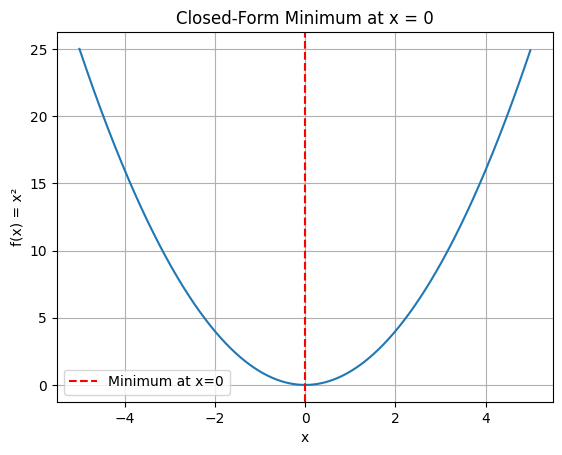

In [1]:
import numpy as np
import matplotlib.pyplot as plt

x = np.arange(-5, 5, 0.01)
y = [i**2 for i in x]

plt.plot(x, y)
plt.xlabel("x")
plt.ylabel("f(x) = x²")
plt.title("Closed-Form Minimum at x = 0")
plt.axvline(0, color='r', linestyle='--', label='Minimum at x=0')
plt.legend()
plt.grid(True)
plt.show()

```
x  y
------
-10 100
... ...
-4 16
-3 9
-2 4  
-1 1
0 0
1 1
2 4
3 9
4 16
.. ..
10 100

```

## Example of a function without closed form solution

$$ f(x) = x^4 + x^2 + sin(x) $$

You can compute the derivative, but solving $\frac{df}{dx} = 0$ does not typically yield a clean symbolic solution.

However, you **can** still find the minimum numerically — which is exactly where gradient descent is useful.

## Simple python function example

```
def square(x):
  return x * x
```
inputs: x
output: x$^2$
Question: which x gives the smallest value of $x^2$?
Answer: (x = 0)

Function: square(x)
Minimum -> lowest point of the curve

In [16]:
square(-3.0)

9.0

# Loss Functions in Machine Learning

In data science and machine learning, the function we minimize is usually called a **loss function** (or objective function).

- **Inputs:** model parameters (e.g., slope and intercept, weights in a neural network)
- **Output:** a number measuring how "bad" the model is

So minimizing a function means:

> Choose model parameters that make the model’s error as small as possible.

---

## Examples

- Minimize **Sum of Squared Errors (SSE)**
- Minimize **Mean Squared Error (MSE)** [ https://en.wikipedia.org/wiki/Mean_squared_error ]
- Minimize **Log Loss** (classification problems)
- Tune model parameters in neural networks

---

## Why This Matters

In real machine learning problems:

- Loss functions can be complicated
- There may be **many parameters**
- The function may be high-dimensional
- The loss may be a sum of millions of terms

Even when derivatives exist, solving them exactly is often impossible.

This is why gradient descent is essential.

# Example Setup: Linear Regression

Suppose we have data:

$$
(x_1, y_1), (x_2, y_2), ..., (x_n, y_n)
$$

In table form:

| **i**  | **xᵢ**  | **yᵢ**  | $\hat{y_{i}}$| e_i |
|-------|--------|--------|---------| --------
| 1  | x₁  | y₁  | - | - |
| 2  | x₂  | y₂  | - | -|
| 3  | x₃  | y₃  | - | _ |
| ⋮  | ⋮   | ⋮   |
| n  | xₙ  | yₙ  | - | - |


We assume a linear model:

$$
\widehat{y} = mx + b
$$

Our goal is to choose parameters:

$$
\theta = (m, b)
$$

that minimize the error between predicted values and actual values.

## Define the Loss Function

### Squared Error Loss (Single Data Point)

For one data point:

$$
L_i(m, b) = (mx_i + b - y_i)^2
$$

---

### Mean Squared Error (All Data Points)

$$
L(m, b) = \frac{1}{n} \sum_{i=1}^{n} (mx_i + b - y_i)^2
$$

This is the function we want to minimize.

## Why Do We Take Derivatives with Respect to m and b?

- ($x_i$\) and \($y_i$\) are data — fixed.
- \(m\) and \(b\) are parameters — we can change them.

So we ask:

- If I slightly change **m**, how does the loss change?
- If I slightly change **b**, how does the loss change?

That is why we compute the gradient:

$$
\nabla_\theta L =
\left[
\frac{\partial L}{\partial m},
\frac{\partial L}{\partial b}
\right]
$$

The gradient tells us the direction of steepest increase.
To reduce loss, we move in the **negative gradient direction**.

## Deriving the Gradient

### 1. Derive Partial Derivatives (Single Data Point First)

Start simple.

For one data point:

$$L_i(m,b) = (mx_i + b - y_i)^2$$

Define:

$$ e_i = mx_i + b - y_i$$

Then:

$$ L_i = e_i^2 $$

Now apply chain rule.

⸻

Derivative w.r.t m

$$
\frac{\partial L_i}{\partial m}
=
\frac{\partial (e_i^2)}{\partial e_i}
\cdot
\frac{\partial e_i}{\partial m}$$

We know:
	•	$\frac{\partial (e^2)}{\partial e} = 2e$
	•	$\frac{\partial e}{\partial m} = x_i$

So:

$$\frac{\partial L_i}{\partial m}
=
2 e_i x_i
=
2 (mx_i + b - y_i) x_i$$

⸻

Derivative w.r.t b

$$\frac{\partial L_i}{\partial b}
=
2 e_i
=
2 (mx_i + b - y_i)$$

⸻

### 2. Then Extend to Full Dataset (Mean Loss)

Now move from one point to all points.

We minimize:

$$L(m,b) = \frac{1}{n} \sum_{i=1}^n L_i(m,b)$$

A key calculus rule:

Gradient of a sum = sum of gradients

So:

$$\frac{\partial L}{\partial m}
=
\frac{1}{n} \sum_{i=1}^n 2 (mx_i + b - y_i)x_i$$

$$\frac{\partial L}{\partial b}
=
\frac{1}{n} \sum_{i=1}^n 2 (mx_i + b - y_i)$$

In [2]:
# ==== Course setup: safe clone + cd + import path ====
import os
import sys

REPO_URL = "https://github.com/joelgrus/data-science-from-scratch.git"
REPO_DIR = "data-science-from-scratch"

# 1. If we're *anywhere inside* the repo, move to the parent directory first
cwd = os.getcwd()
if REPO_DIR in cwd.split(os.sep):
    parts = cwd.split(os.sep)
    # Walk up until we are at .../data-science-from-scratch
    while parts and parts[-1] != REPO_DIR:
        parts.pop()
    # Now go to the directory *above* the repo
    parent_dir = os.sep.join(parts[:-1]) or "/"
    os.chdir(parent_dir)
    print(f"Moved to parent directory: {os.getcwd()}")

# 2. Clone only if needed
if not os.path.exists(REPO_DIR):
    print("Cloning repo...")
    !git clone {REPO_URL}
else:
    print(f"{REPO_DIR} already exists — skipping clone.")

# 3. cd into the repo (this is where you'll live most of the time)
%cd {REPO_DIR}

# 4. Ensure the repo is importable (for scratch.linear_algebra, etc.)
if os.getcwd() not in sys.path:
    sys.path.append(os.getcwd())
    print("Added repo to sys.path")

data-science-from-scratch already exists — skipping clone.
/content/data-science-from-scratch
Added repo to sys.path


In [3]:
# Vector: List of floats
from typing import List

Vector = List[float]

**Gradient of the linear regression loss:**

$$\frac{\partial L_i}{\partial m} = 2(mx_i + b - y_i)x_i$$

$$\frac{\partial L_i}{\partial b} = 2(mx_i + b - y_i)$$

In [4]:
def linear_gradient(x: float, y: float, theta: Vector) -> Vector:
    slope, intercept = theta
    predicted = slope * x + intercept
    error = predicted - y
    grad = [2 * error * x, 2 * error]
    return grad

## Now we are ready to update

## The Gradient Descent Update Rule

Let:

$$
\theta = (m, b)
$$

Then the update rule is:

$$
\theta \leftarrow \theta - \eta \nabla L(\theta)
$$

where:

- \( $\eta$ \) is the learning rate
- $ \nabla L(\theta) $ is the gradient

# Show GD on a Toy Function

## Using the Gradient to Minimize a Function

Before fitting a model, let’s see gradient descent work on a simple function.

Consider:

$$
f(v) = v_1^2 + v_2^2 + v_3^2
$$

The gradient is:

$$
\nabla f(v) = [2v_1, 2v_2, 2v_3]
$$

The minimum occurs at:

$$
v = [0, 0, 0]
$$

Let’s see if gradient descent can find it.

In [5]:
import numpy as np

# Meshgrid example
x = np.array([1, 2, 3])
y = np.array([10, 20])

X, Y = np.meshgrid(x, y)

print("X =\n", X)
print("Y =\n", Y)

X =
 [[1 2 3]
 [1 2 3]]
Y =
 [[10 10 10]
 [20 20 20]]


We are plotting the function $f(v_1, v_2) = v_1^2 + v_2^2$, which represents the squared distance from the origin. The contour lines should form concentric circles (points with equal function value), and the gradient arrows should point outward, perpendicular to the contours. The arrows will be smaller near the center and larger farther away because the surface becomes steeper as distance from the origin increases.

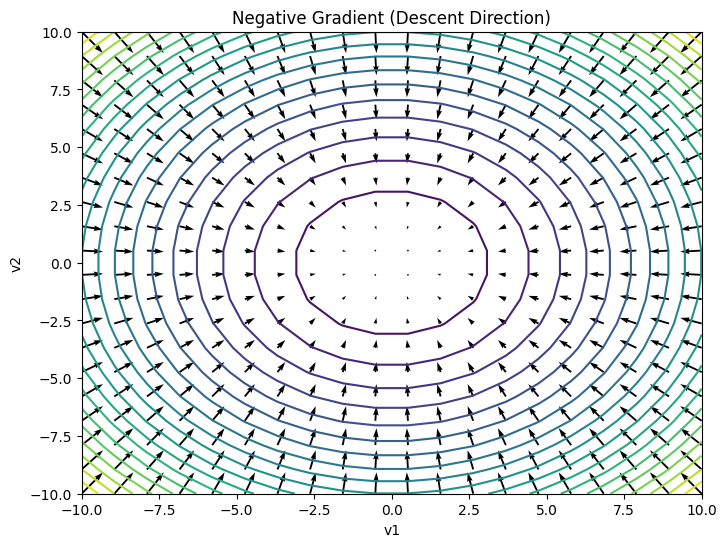

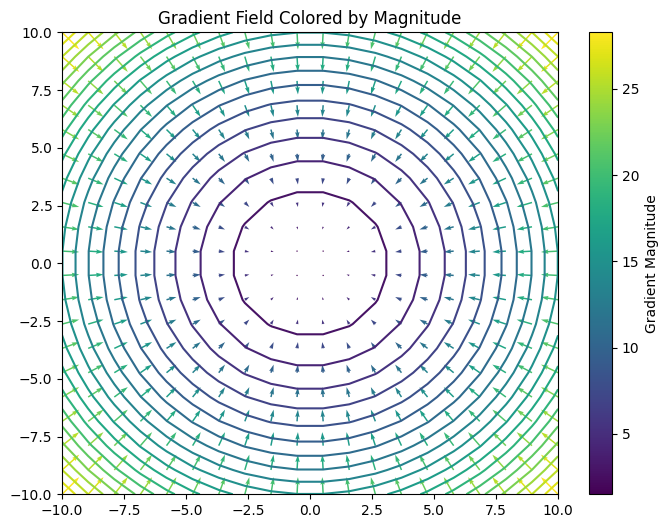

In [17]:
import numpy as np
import matplotlib.pyplot as plt

# Grid
v1 = np.linspace(-10, 10, 20)
v2 = np.linspace(-10, 10, 20)
V1, V2 = np.meshgrid(v1, v2)

# Function
F = V1**2 + V2**2

# Gradient
dF_dv1 = 2*V1
dF_dv2 = 2*V2

# Negative gradient (descent direction)
neg_dF_dv1 = -dF_dv1
neg_dF_dv2 = -dF_dv2

plt.figure(figsize=(8,6))
plt.contour(V1, V2, F, levels=20)
plt.quiver(V1, V2, neg_dF_dv1, neg_dF_dv2)

plt.xlabel("v1")
plt.ylabel("v2")
plt.title("Negative Gradient (Descent Direction)")
plt.show()
magnitude = np.sqrt(dF_dv1**2 + dF_dv2**2)

plt.figure(figsize=(8,6))
plt.contour(V1, V2, F, levels=20)
plt.quiver(V1, V2, neg_dF_dv1, neg_dF_dv2, magnitude)

plt.title("Gradient Field Colored by Magnitude")
plt.colorbar(label="Gradient Magnitude")
plt.show()

# Key points

* Gradient, $\nabla f(v)$ is a vector
  * It has both Direction and Magnitude
  * Magnitude: $$\|\nabla f(v)\|$$ It tells you:

    How fast the function is changing locally.

    Large magnitude = steep

    Small magnitude = flat
  * Direction: Normalized direction
    $$\frac{\nabla f}{\|\nabla f\|}$$

The gradient provides both direction and slope strength, and the learning rate controls how aggressively we move in that direction.


# Sample functions included in the following code

```
import random
from scratch.linear_algebra import distance, add, scalar_multiply

def gradient_step(v: Vector, gradient: Vector, step_size: float) -> Vector:
    """Moves `step_size` in the `gradient` direction from `v`"""
    assert len(v) == len(gradient)
    step = scalar_multiply(step_size, gradient)
    return add(v, step)

def scalar_multiply(c: float, v: Vector) -> Vector:
    """Multiplies every element by c"""
    return [c * v_i for v_i in v]

def add(v: Vector, w: Vector) -> Vector:
    """Adds corresponding elements"""
    assert len(v) == len(w), "vectors must be the same length"

    return [v_i + w_i for v_i, w_i in zip(v, w)]

def sum_of_squares_gradient(v: Vector) -> Vector:
    return [2 * v_i for v_i in v]
```

`sum_of_squares_gradient` --> `gradient_step` --> `scalar_multiply` --> `add`

In [18]:
# Now the code
import random
from scratch.gradient_descent import *
from scratch.linear_algebra import Vector, dot

v = [random.uniform(-10, 10) for _ in range(3)]
print('Initial V: ', v)

for epoch in range(1000):
    grad = sum_of_squares_gradient(v)
    v = gradient_step(v, grad, -0.01) # note the -0.01 reverses the gradient direction

print(v)

Initial V:  [-3.1661801804030887, 0.3007602373524172, -3.1740935795718173]
[-5.328577890682528e-09, 5.061696618126429e-10, -5.3418958831681036e-09]


In [8]:
assert distance(v, [0, 0, 0]) < 0.001

## Implement the GD Step Mechanism

## Implementing a Gradient Step

We now translate the update rule into code.

Recall the update formula:

$$
\theta \leftarrow \theta - \eta \nabla L(\theta)
$$

This means:

1. Compute the gradient at the current point
2. Multiply it by a step size (learning rate)
3. Subtract it from the current parameters

This moves us slightly in the direction of steepest decrease.

In [9]:
def gradient_step(v: Vector, gradient: Vector, step_size: float) -> Vector:
    """Moves step_size in the gradient direction from v"""
    assert len(v) == len(gradient)
    step = scalar_multiply(step_size, gradient)
    return add(v, step)

Note:

If we want to move downhill, we pass a **negative step size**.

For example:

$$
v = \text{gradient_step}(v, grad, -\text{learning_rate})$$

This subtracts the gradient.

In [10]:
# Now the code

v = [random.uniform(-10, 10) for _ in range(3)]

for epoch in range(1000):
    grad = sum_of_squares_gradient(v)
    v = gradient_step(v, grad, -0.01)

print(v)

[-6.106840814783697e-09, -1.6197250010523494e-08, -1.4529102046214157e-08]


## Using Gradient Descent (GD) to Fit a Linear Model

We now apply gradient descent to fit a straight line:

$$
\widehat{y} = mx + b
$$

Our goal is to learn parameters:

$$
\theta = (m, b)
$$

that minimize the mean squared error (MSE).


## Step 1: Define the Gradient per Data Point

The error is:

$$
e_i = \widehat{y}_i - y_i = (m x_i + b - y_i)
$$

The squared error loss for this one point is:

$$
L_i(m,b) = e_i^2
$$

In [11]:
# def linear_gradient(x: float, y: float, theta: Vector) -> Vector:
#     slope, intercept = theta
#     predicted = slope * x + intercept
#     error = predicted - y
#     return [2 * error * x, 2 * error]

For each data point, this returns:

$$
\nabla L_i =
\left[\:
2(m x_i + b - y_i)x_i, \:
2(m x_i + b - y_i)
\: \right]
$$

Each data point contributes a 2-dimensional gradient vector.

## Step 2: Initialize Parameters



In [12]:
from scratch.linear_algebra import vector_mean

theta = [random.uniform(-1, 1), random.uniform(-1, 1)]
learning_rate = 0.001
print("Slope: ", theta[0], "Learning_Rate: ", learning_rate, "Intercept: ", theta[1])

Slope:  0.7385611444574884 Learning_Rate:  0.001 Intercept:  0.14853168745466672


## Step 3: Full Batch GD



```
Remember:
# x ranges from -50 to 49, y is always 20 * x + 5
inputs = [(x, 20 * x + 5) for x in range(-50, 50)]
```

At each epoch:

1. Compute gradient for every data point
2. Average all gradients (because we minimize mean loss)
3. Update parameters once

This is called **Batch Gradient Descent**.

## Limitations of Batch Gradient Descent, Why Full Batch is not Enough?

So far, at each epoch we:

1. Computed gradients for all data points
2. Averaged them
3. Updated parameters once

This works well for small datasets.

However, in real-world machine learning problems:

- Datasets may contain millions (or billions) of samples
- Computing gradients over the entire dataset can be expensive
- Updates happen slowly (only once per full pass)

Can we update parameters more frequently?

## Mini-Batch Gradient Descent

Instead of computing gradients using the entire dataset, we:

- Split the data into small batches
- Compute gradients on each batch
- Update parameters after each batch

This means:

- More frequent updates
- Less computation per update
- Faster learning in practice

In [13]:
theta = [random.uniform(-1, 1), random.uniform(-1, 1)]

for epoch in range(1000):
    for batch in minibatches(inputs, batch_size=20):
        grad = vector_mean([linear_gradient(x, y, theta) for x, y in batch])
        theta = gradient_step(theta, grad, -learning_rate)

print("Final theta:", theta)

Final theta: [20.0000006262319, 4.999998420246666]


## Stochastic Gradient Descent (SGD)

In stochastic gradient descent:

- Batch size = 1
- We update parameters after each individual example

This produces noisy updates but often converges faster in practice.

In [14]:
# Now comes the code

theta = [random.uniform(-1, 1), random.uniform(-1, 1)]

for epoch in range(100):
    for x, y in inputs:
        grad = linear_gradient(x, y, theta)
        theta = gradient_step(theta, grad, -learning_rate)

print("Final theta:", theta)

Final theta: [20.001355558993986, 4.932530806461731]


## Big Picture & Comparison

| Method | Batch Size | Updates per Epoch | Stability | Speed |
|--------|------------|------------------|-----------|--------|
| Batch GD | All data | 1 | Very stable | Slower per update |
| Mini-Batch | Small subset | Many | Balanced | Fast |
| SGD | 1 | n | Noisy | Very fast updates |